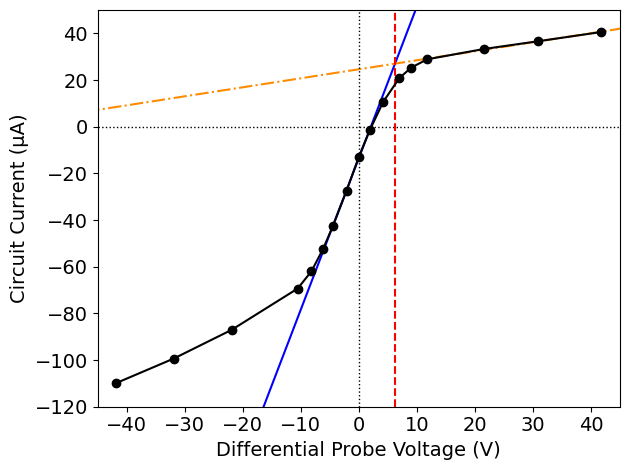

Resultado:
Te (eV) = 2.080 eV
I_sat = 27.009 µA
dI/dV |0 = 6.493 µA/V


In [52]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


def fit_line(V, I, vmin, vmax):
    mask = (V >= vmin) & (V <= vmax)

    if np.sum(mask) < 2:
        raise ValueError(
            f"Interval [{vmin},{vmax}] não tem pontos suficientes para ajuste."
        )

    slope, intercept, r, p, se = stats.linregress(V[mask], I[mask])

    return slope, intercept, mask


def calcular_Te(
    V,
    I,
    manual_pos_range,
    manual_sat_range,
    plot=True,
    I_not_in_microamp=True
):

    V = np.asarray(V)
    I = np.asarray(I, dtype=float)

    if I_not_in_microamp:
        I = I * 1e6  # A -> µA

    # ordenar
    order = np.argsort(V)
    V = V[order]
    I = I[order]

    pos_vmin, pos_vmax = manual_pos_range
    sat_vmin, sat_vmax = manual_sat_range

    # reta próxima de zero
    slope_pos, intercept_pos, mask_pos = fit_line(
        V, I,
        pos_vmin, pos_vmax
    )

    # reta de saturação
    try:
        slope_sat, intercept_sat, mask_sat = fit_line(
            V, I,
            sat_vmin, sat_vmax
        )

    except Exception:

        sat_vmax2 = sat_vmin + (sat_vmax - sat_vmin) * 0.6

        slope_sat, intercept_sat, mask_sat = fit_line(
            V, I,
            sat_vmin,
            sat_vmax2
        )

    # interseção
    if slope_pos == slope_sat:
        raise RuntimeError(
            "As duas retas ficaram paralelas; escolha outras janelas."
        )

    V_intersect = (
        (intercept_sat - intercept_pos)
        / (slope_pos - slope_sat)
    )

    Isat = slope_pos * V_intersect + intercept_pos

    # dI/dV em V≈0
    dIdV = slope_pos

    # Te
    Te = Isat / (2.0 * dIdV)

    result = {
        "Te_eV": Te,
        "Isat_A": Isat,
        "dIdV_AperV": dIdV,
        "V_intersect": V_intersect,
        "slope_pos": slope_pos,
        "intercept_pos": intercept_pos,
        "slope_sat": slope_sat,
        "intercept_sat": intercept_sat,
        "mask_pos": mask_pos,
        "mask_sat": mask_sat,
        "V": V,
        "I": I,
        "pos_range": manual_pos_range,
        "sat_range": manual_sat_range,
    }

    if plot:

        xerr = [0.1] * len(V)
        yerr = [0.1] * len(I)

        plt.errorbar(
            V,
            I,
            xerr=xerr,
            yerr=yerr,
            fmt='o-',
            color='black',
            ecolor='black',
            capsize=3,
            label='i = 16 mA\np = 0.9 mbar'
        )

        Vlin = np.linspace(np.min(V), np.max(V), 500)

        plt.plot(
            Vlin,
            slope_pos * Vlin + intercept_pos,
            color='blue',
            linewidth=1.5,
            label='Ajuste linear'
        )

        Vlin_sat = np.linspace(-100, 100, 2)

        plt.plot(
            Vlin_sat,
            slope_sat * Vlin_sat + intercept_sat,
            color='darkorange',
            linestyle='-.',
            linewidth=1.5,
            label='Saturação'
        )

        plt.axhline(
            0,
            color='black',
            linestyle=':',
            linewidth=1
        )

        plt.axvline(
            0,
            color='black',
            linestyle=':',
            linewidth=1
        )

        plt.axvline(
            V_intersect,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'$I_{{sat}}$ = {Isat:.2f} µA'
        )

        plt.xticks(fontsize=14)
        plt.yticks(
            np.arange(-200, 201, 20),
            fontsize=14
        )

        plt.xlabel(
            'Differential Probe Voltage (V)',
            fontsize=14
        )

        plt.ylabel(
            'Circuit Current (µA)',
            fontsize=14
        )

        #Ajuste manual da escala do gráfico
        plt.xlim(-45, 45)
        plt.ylim(-120, 50)

        plt.tight_layout()
        plt.show()

    return result


# -------------------------
# Aqui o ajuste será realizado
# Por os dados de interesse
# -------------------------

if __name__ == "__main__":

    V = np.array([
        -41.90, -31.87, -21.89, -10.54, -8.17,
        -6.14, -4.49, -2.114, 0.0, 1.896,
         4.21,  6.95,  8.99, 11.81, 21.51,
        30.79, 41.70
    ]) #Em V

    I = np.array([
        -109.9700e-6, -99.3393e-6, -87.0270e-6,
         -69.3694e-6, -61.9820e-6, -52.3123e-6,
         -42.7027e-6, -27.4474e-6, -12.9129e-6,
          -1.44144e-6, 10.6907e-6, 20.7207e-6,
          25.2853e-6, 28.8889e-6, 33.2733e-6,
          36.5766e-6, 40.5405e-6
    ]) #Em A (se dados estiverem em µA, por I_not_in_microamp = False)

    #Ajuste manual das regiões
    res = calcular_Te(
        V,
        I,
        manual_pos_range=(-2.114, 1.896),
        manual_sat_range=(11.81, 41.70),
        plot=True,
        I_not_in_microamp=True
    )

    print("Resultado:")
    print(f"Te (eV) = {res['Te_eV']:.3f} eV")
    print(f"I_sat = {res['Isat_A']:.3f} µA")
    print(f"dI/dV |0 = {res['dIdV_AperV']:.3f} µA/V")

# Calculos

## Campo Elétrico Reduzido

In [48]:
k_B = 1.380649e-23 #Constante de Boltzmann em J/K

P = 1.8 * 100 #Pressão (Pa)
T = 350 #Temperatura (estimada por Temperatura Rotacional) (K)
V = 3.2 #Tensão entre as sondas (V)
d = 2.64e-3 #Separação entre as sondas (m)

E = V/d
N = P / (k_B * T)
EN = (E/N) * 1e21

print(f"E = {E} V/m")
print(f"N = {N} 1/m³")
print(f"E/N = {EN} Td")

E = 1212.1212121212122 V/m
N = 3.7249562653919585e+22 1/m³
E/N = 32.54054882154883 Td


## Área da sonda

In [49]:
import math

#Sonda cilíndrica

pi = math.pi
diametro = 3e-3 #Diametro da sonda em metro
comp = 3.38e-3 #Comprimento da sonda em metro

Ab = pi * (diametro/2) * (diametro/2) #Área da base

A = Ab + (comp * (2 * pi * (diametro/2))) #Área lateral + base

print(f"A = {A} m²")

A = 3.892433297797754e-05 m²


## Cálculo do $n_e$

In [50]:
Is = 107.633e-6 #Corrente de Saturação, em A
e = 1.602176634e-19 #Carga fundamental em C
vd = 38000 #Velocidade de drift estimada no Bolsig usando o E/N (m/s)

#Da equação de continuidade (A sendo a área calculada no item anterior):
ne = (Is) / (e * A * vd)

print(f"ne = {ne:.1e} 1/m³")

ne = 4.5e+14 1/m³


## Cálculo do grau de ionização $n_e / n_x$

In [51]:
#Dado N e ne, basta calcular

ne_nx = ne / N

print(f"ne/nx = {ne_nx:.1e}")

ne/nx = 1.2e-08
